In [1]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Freshlync Sales Prediction: XGBoost Model

**Goal**: Build an XGBoost regressor to predict `quantity_sold` and compare performance against the Linear Regression baseline.

1. Load & preprocess data (same pipeline as baseline)
2. Train XGBoost with default params
3. Hyperparameter tuning with RandomizedSearchCV
4. Evaluate & compare RMSE with baseline
5. Feature importance analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Load and Preprocess Data (same pipeline as the baseline so results are comparable)

In [3]:
# Load data
df = pd.read_csv('../data/sample_orders.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1000, 8)


,date,product_name,category,quantity_sold,price,day_of_week,is_holiday,weather_condition
0,2023-01-01,Tomato,vegetable,122,564.17,Sunday,0,sunny
1,2023-01-01,Seer Fish,fish,96,1625.21,Sunday,1,cloudy
2,2023-01-02,Pork,meat,127,855.60,Monday,0,cloudy
3,2023-01-02,Potato,vegetable,114,943.85,Monday,0,rainy
4,2023-01-03,Beans,vegetable,106,839.25,Tuesday,0,rainy


In [4]:
# Same features and preprocessing as the linear regression baseline
X = df[['product_name', 'category', 'price', 'day_of_week', 'is_holiday', 'weather_condition']]
y = df['quantity_sold']

categorical_cols = ['product_name', 'category', 'day_of_week', 'weather_condition']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)
print(f'Processed feature matrix shape: {X_processed.shape}')

# Train/test split (identical to baseline)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Processed feature matrix shape: (1000, 19)
Train: (800, 19), Test: (200, 19)


---
## 2. Train XGBoost with Default Hyperparameters

In [5]:
# Default XGBoost regressor
xgb_default = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_default.fit(X_train, y_train)

# Predictions
y_pred_train_default = xgb_default.predict(X_train)
y_pred_test_default = xgb_default.predict(X_test)

# RMSE
rmse_train_default = np.sqrt(mean_squared_error(y_train, y_pred_train_default))
rmse_test_default = np.sqrt(mean_squared_error(y_test, y_pred_test_default))

print(f'XGBoost (Default) - Train RMSE: {rmse_train_default:.2f}')
print(f'XGBoost (Default) - Test  RMSE: {rmse_test_default:.2f}')
print(f'Overfit gap: {rmse_train_default - rmse_test_default:.2f}')

XGBoost (Default) - Train RMSE: 19.45
XGBoost (Default) - Test  RMSE: 39.62
Overfit gap: -20.17


### 2.1 Actual vs Predicted (Default Model)

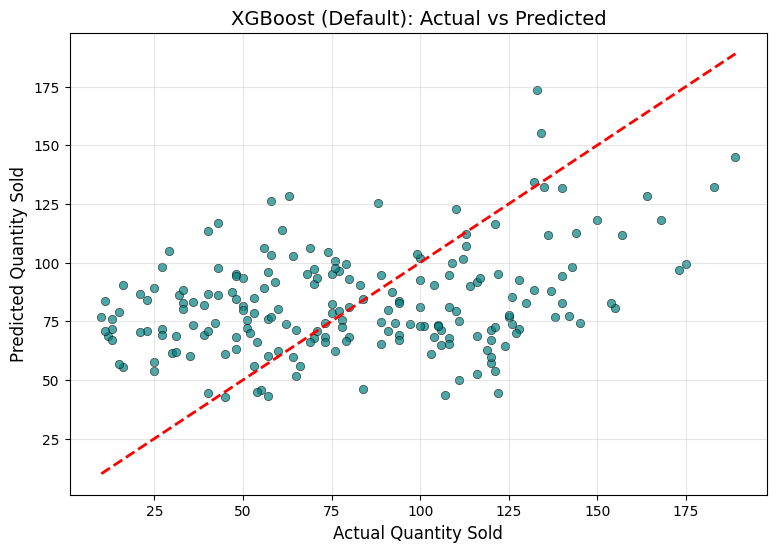

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_test_default, alpha=0.7, color='teal', edgecolor='black')
min_val = min(y_test.min(), y_pred_test_default.min())
max_val = max(y_test.max(), y_pred_test_default.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.title('XGBoost (Default): Actual vs Predicted', fontsize=14)
plt.xlabel('Actual Quantity Sold', fontsize=12)
plt.ylabel('Predicted Quantity Sold', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

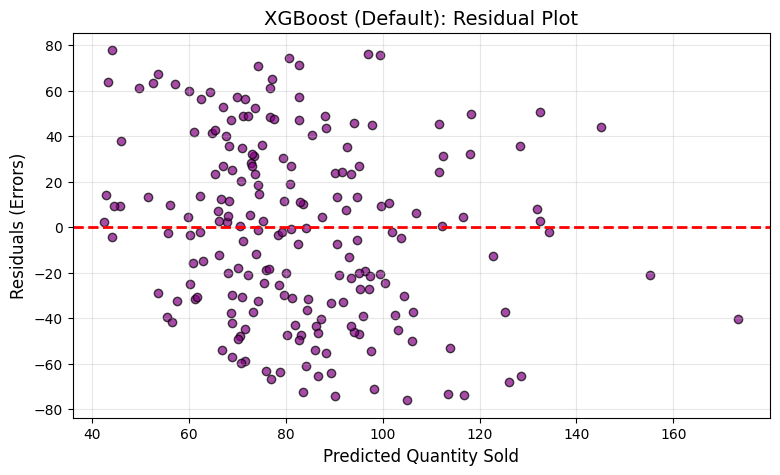

In [7]:
residuals_default = y_test - y_pred_test_default

plt.figure(figsize=(9, 5))
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.scatter(y_pred_test_default, residuals_default, alpha=0.7, color='purple', edgecolor='black')
plt.title('XGBoost (Default): Residual Plot', fontsize=14)
plt.xlabel('Predicted Quantity Sold', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

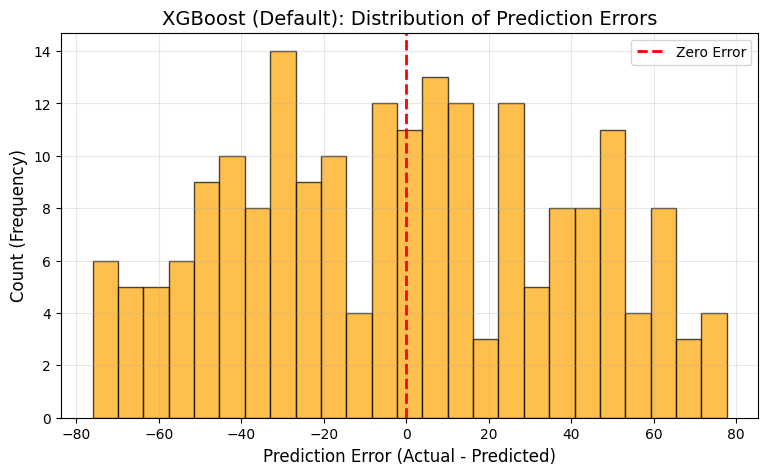

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(residuals_default, bins=25, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
plt.title('XGBoost (Default): Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Count (Frequency)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. Hyperparameter Tuning with RandomizedSearchCV

In [9]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 3]
}

xgb_tune = XGBRegressor(random_state=42, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=30,           # try 30 random combinations
    scoring='neg_root_mean_squared_error',
    cv=3,                # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f'\nBest parameters: {random_search.best_params_}')
print(f'Best CV RMSE: {-random_search.best_score_:.2f}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE: 35.10


In [10]:
# Best model from tuning
xgb_best = random_search.best_estimator_

y_pred_train_tuned = xgb_best.predict(X_train)
y_pred_test_tuned = xgb_best.predict(X_test)

rmse_train_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
rmse_test_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))

print(f'XGBoost (Tuned)  - Train RMSE: {rmse_train_tuned:.2f}')
print(f'XGBoost (Tuned)  - Test  RMSE: {rmse_test_tuned:.2f}')
print(f'Overfit gap: {rmse_train_tuned - rmse_test_tuned:.2f}')

XGBoost (Tuned)  - Train RMSE: 31.69
XGBoost (Tuned)  - Test  RMSE: 36.29
Overfit gap: -4.59


---
## 4. Compare Against Linear Regression Baseline

In [11]:
# Baseline RMSE values from the linear regression notebook
BASELINE_TRAIN_RMSE = 33.63
BASELINE_TEST_RMSE  = 35.94

comparison = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'Train RMSE': [BASELINE_TRAIN_RMSE, rmse_train_default, rmse_train_tuned],
    'Test RMSE':  [BASELINE_TEST_RMSE,  rmse_test_default,  rmse_test_tuned],
    'Overfit Gap': [
        BASELINE_TRAIN_RMSE - BASELINE_TEST_RMSE,
        rmse_train_default - rmse_test_default,
        rmse_train_tuned - rmse_test_tuned
    ]
})

print('=== Model Comparison ===')
print(f'{"Model":<35} {"Train RMSE":<15} {"Test RMSE":<15} {"Gap":<10}')
print('-' * 75)
for _, row in comparison.iterrows():
    print(f'{row["Model"]:<35} {row["Train RMSE"]:<15.2f} {row["Test RMSE"]:<15.2f} {row["Overfit Gap"]:<10.2f}')

improvement = ((BASELINE_TEST_RMSE - rmse_test_tuned) / BASELINE_TEST_RMSE) * 100
print(f'\nXGBoost (Tuned) RMSE improvement over baseline: {improvement:+.1f}%')

=== Model Comparison ===
Model                               Train RMSE      Test RMSE       Gap       
---------------------------------------------------------------------------
Linear Regression (Baseline)        33.63           35.94           -2.31     
XGBoost (Default)                   19.45           39.62           -20.17    
XGBoost (Tuned)                     31.69           36.29           -4.59     

XGBoost (Tuned) RMSE improvement over baseline: -1.0%


### 4.1 RMSE Comparison Bar Chart

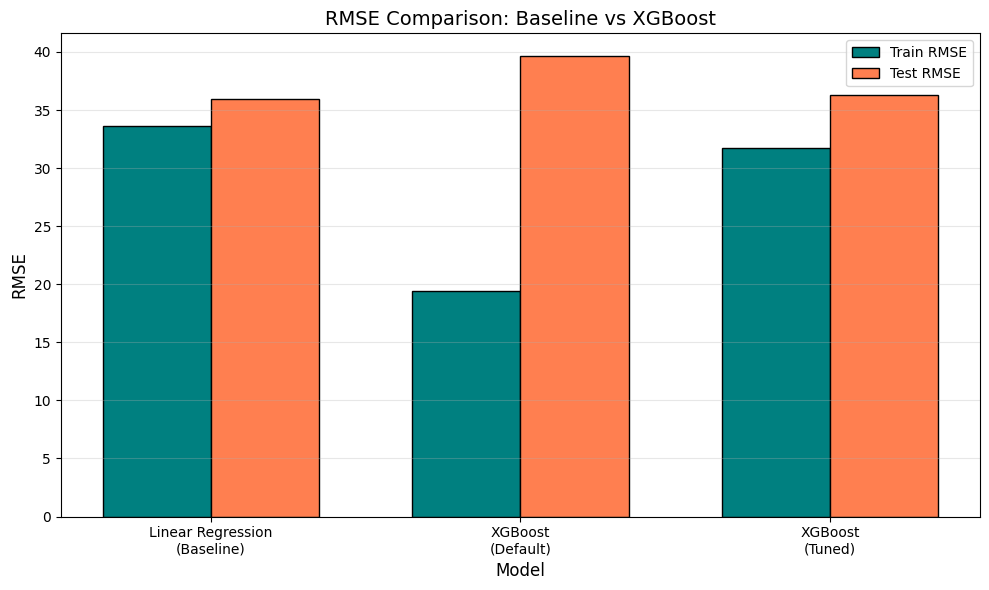

In [12]:
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison['Model']))
width = 0.35

plt.bar(x - width/2, comparison['Train RMSE'], width, label='Train RMSE', color='teal', edgecolor='black')
plt.bar(x + width/2, comparison['Test RMSE'], width, label='Test RMSE', color='coral', edgecolor='black')

plt.xlabel('Model', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE Comparison: Baseline vs XGBoost', fontsize=14)
plt.xticks(x, ['Linear Regression\n(Baseline)', 'XGBoost\n(Default)', 'XGBoost\n(Tuned)'], fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 5. Visualizations (Tuned Model)

### 5.1 Actual vs Predicted (Tuned Model)

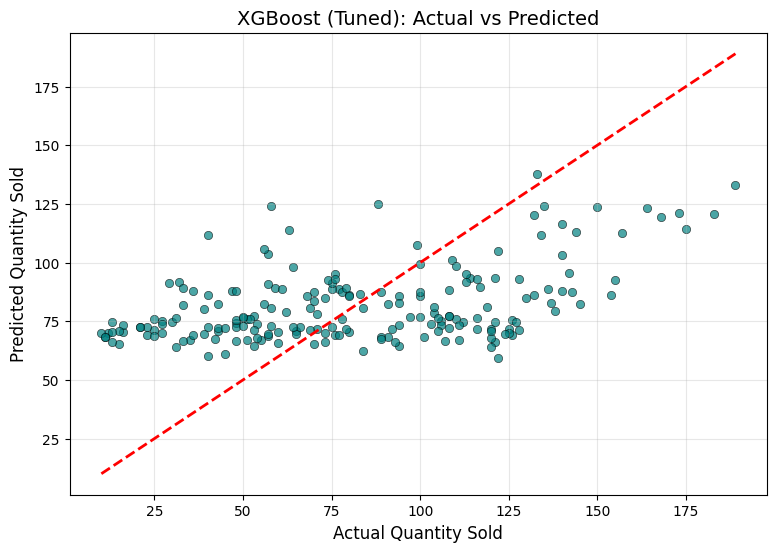

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_test_tuned, alpha=0.7, color='teal', edgecolor='black')
min_val = min(y_test.min(), y_pred_test_tuned.min())
max_val = max(y_test.max(), y_pred_test_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.title('XGBoost (Tuned): Actual vs Predicted', fontsize=14)
plt.xlabel('Actual Quantity Sold', fontsize=12)
plt.ylabel('Predicted Quantity Sold', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Residual Plot

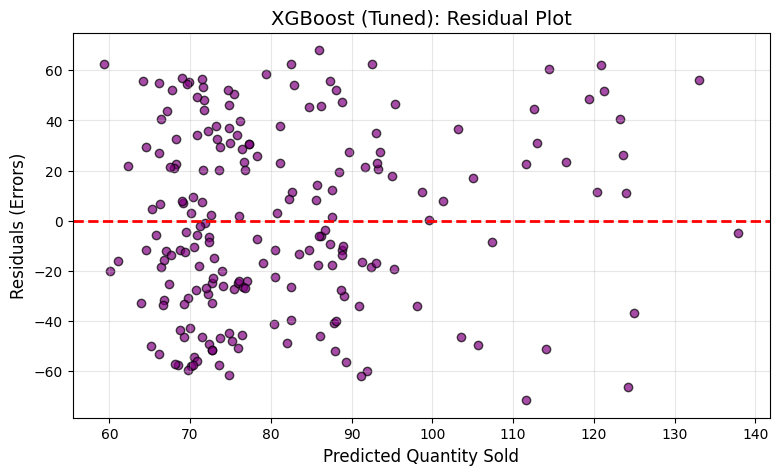

In [14]:
residuals = y_test - y_pred_test_tuned

plt.figure(figsize=(9, 5))
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.scatter(y_pred_test_tuned, residuals, alpha=0.7, color='purple', edgecolor='black')
plt.title('XGBoost (Tuned): Residual Plot', fontsize=14)
plt.xlabel('Predicted Quantity Sold', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 5.3 Error Distribution

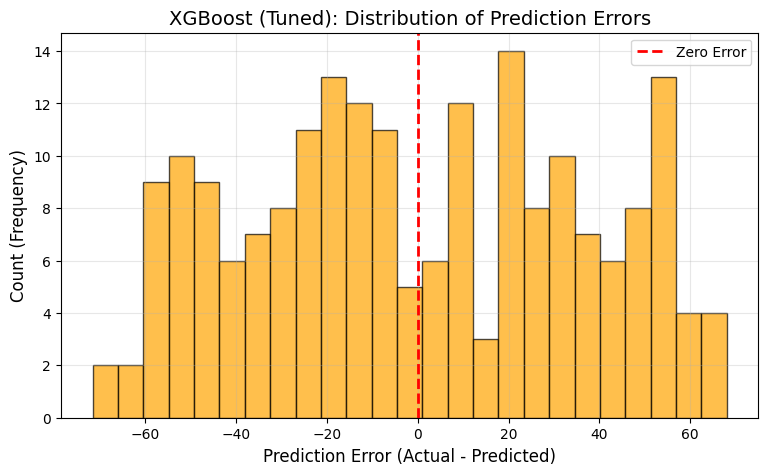

In [15]:
plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=25, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
plt.title('XGBoost (Tuned): Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Count (Frequency)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 6. Feature Importance

XGBoost provides native feature importance. We map the one-hot encoded columns back to readable names.

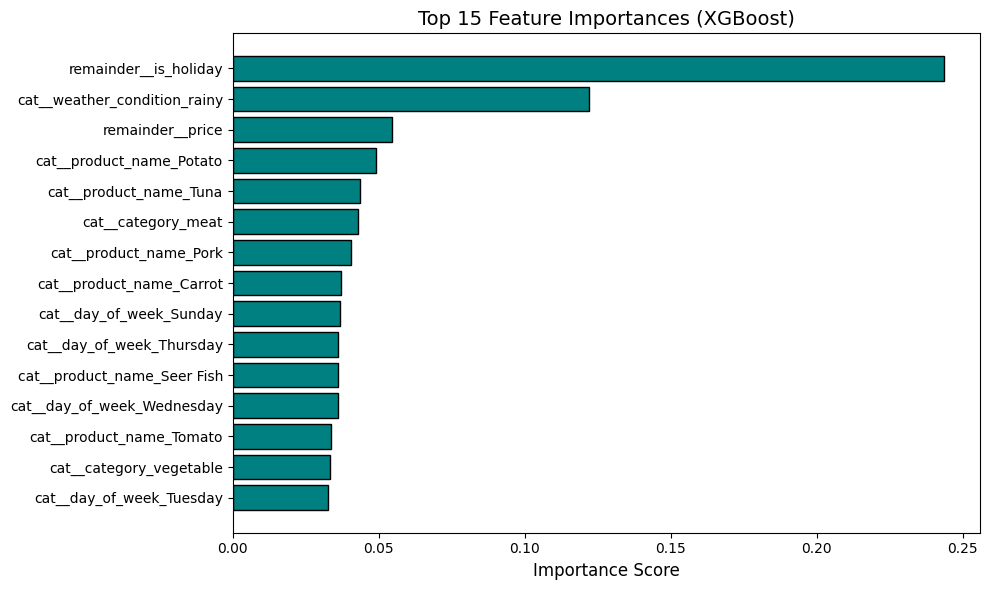


Top 10 Features:


,Feature,Importance
18,remainder__is_holiday,0.243774
15,cat__weather_condition_rainy,0.122205
17,remainder__price,0.054647
3,cat__product_name_Potato,0.049064
6,cat__product_name_Tuna,0.043469
7,cat__category_meat,0.042744
2,cat__product_name_Pork,0.040351
0,cat__product_name_Carrot,0.037133
11,cat__day_of_week_Sunday,0.036688
12,cat__day_of_week_Thursday,0.036196


In [16]:
# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Importance scores from XGBoost
importance_scores = xgb_best.feature_importances_

# Build DataFrame sorted by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
colors = ['teal' if imp > 0.02 else 'slategray' for imp in importance_df['Importance'].head(15)]
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15), color=colors, edgecolor='black')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 Features:')
importance_df.head(10)

---
## Summary

**What we did:**
- Built an XGBoost regressor using the same features as the linear regression baseline
- Trained a default model, then tuned hyperparameters via RandomizedSearchCV (30 combos, 3-fold CV)
- Compared RMSE against the baseline
- Visualized predictions, residuals, errors, and feature importance

**Key advantages of XGBoost over Linear Regression:**
- Captures non-linear relationships automatically
- Handles feature interactions (e.g., weather × product category)
- Built-in regularization to prevent overfitting
- Provides native feature importance for interpretability

**Expected outcome:** XGBoost (tuned) should have a lower Test RMSE compared to the linear regression baseline.